# Phase 1 (unsupervised variant): mTAND autoencoder on the toy irregular-sine dataset

The other Phase 1 notebook (`phase1_mtand_baseline.ipynb`) trains the
encoder against the known `period` factor as a labeled sanity task. That's
useful as a first check, but it assumes a label we won't generally have --
the actual goal is **unsupervised representation learning**.

This notebook swaps the regression head for mTAND's actual
encoder-decoder pair (`enc_mtan_rnn` / `dec_mtan_rnn` in the official
`reml-lab/mTAN` repo), trained with a **reconstruction loss only**. No
`period` label appears anywhere in the training loop -- it's used
afterwards, purely as a diagnostic, to check whether the unsupervised
representation happens to make the known factor linearly recoverable.
That check matters for Phase 2: DIOSC's contrastive loss needs a
representation that already carries usable factor information to
disentangle, and reconstruction alone doesn't guarantee that.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data.toy_sine import ToySineDataset, collate_toy_sine
from src.mtand.model import MTANReconEncoder, MTANReconDecoder, MTANAutoencoder

%matplotlib inline
SEED = 0
T_MAX = 20.0
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Data (same toy generator as the supervised notebook)

Same `ToySineDataset` / `collate_toy_sine` as before -- irregularly-sampled
noisy `sin(x / period)`, `period ~ Gamma(1, 1)`. We'll only ever look at
`period` after training, as a diagnostic.

In [2]:
N_SERIES = 5000
full_ds = ToySineDataset(n_series=N_SERIES, seed=SEED, t_max=T_MAX)
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [int(0.9 * N_SERIES), N_SERIES - int(0.9 * N_SERIES)],
    generator=torch.Generator().manual_seed(SEED))

def collate(batch):
    return collate_toy_sine(batch, t_max=T_MAX)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

x, t, period = next(iter(train_loader))
print('x (values, mask):', x.shape, ' time_steps:', t.shape)

x (values, mask): torch.Size([64, 34, 2])  time_steps: torch.Size([64, 34])


## 2. mTAND autoencoder

`MTANReconEncoder` keeps the **full reference-point sequence**
(`num_ref` latent vectors per series) rather than pooling to one vector
like the classifier-style `MTANEncoder` from the supervised notebook did --
that matches the official `enc_mtan_rnn`, and preserving temporal
structure in the latent is what lets the decoder reconstruct (or query)
arbitrary timestamps.

`MTANReconDecoder` (adapted from `dec_mtan_rnn`) cross-attends from any
requested query timestamps back into that reference-point latent sequence.
Critically, the query timestamps at decode time don't have to be the ones
the encoder saw -- we'll use that below to plot a dense, continuous
reconstructed curve, not just point reconstructions.

We dropped the VAE mean/logvar split from the official model: this is a
plain deterministic autoencoder. DIOSC's variational framing is a Phase 2
decision, not one to fold in here.

In [3]:
NUM_REF = 32
NHIDDEN = 32
EMBED_TIME = 32
LATENT_DIM = 8

query = torch.linspace(0, 1, NUM_REF)
encoder = MTANReconEncoder(input_dim=1, query=query, latent_dim=LATENT_DIM, nhidden=NHIDDEN,
                            embed_time=EMBED_TIME, num_heads=1, learn_emb=True)
decoder = MTANReconDecoder(input_dim=1, query=query, latent_dim=LATENT_DIM, nhidden=NHIDDEN,
                            embed_time=EMBED_TIME, num_heads=1, learn_emb=True)
model = MTANAutoencoder(encoder, decoder)

with torch.no_grad():
    recon, z, enc_attn, dec_attn = model(x, t)
print('reconstruction:', recon.shape, ' latent sequence z:', z.shape)

reconstruction: torch.Size([64, 34])  latent sequence z: torch.Size([64, 32, 8])


## 3. Train: masked reconstruction MSE, no labels

The loss only counts real (unpadded) observations -- `mask` marks which
positions in the padded batch are real. `period` never appears in this
loop.

In [4]:
EPOCHS = 60
LR = 1e-3
opt = torch.optim.Adam(model.parameters(), lr=LR)

def masked_mse(recon, y, mask):
    return ((recon - y) ** 2 * mask).sum() / mask.sum()

def evaluate(loader):
    model.eval()
    total_loss, total_mask = 0.0, 0.0
    recon_all, target_all = [], []
    with torch.no_grad():
        for xb, tb, pb in loader:
            yb, maskb = xb[:, :, 0], xb[:, :, 1]
            recon, z, _, _ = model(xb, tb)
            total_loss += ((recon - yb) ** 2 * maskb).sum().item()
            total_mask += maskb.sum().item()
            recon_all.append(recon[maskb.bool()])
            target_all.append(yb[maskb.bool()])
    mse = total_loss / total_mask
    recon_all = torch.cat(recon_all).numpy()
    target_all = torch.cat(target_all).numpy()
    corr = float(np.corrcoef(recon_all, target_all)[0, 1])
    return mse, corr

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, n = 0.0, 0
    for xb, tb, pb in train_loader:
        yb, maskb = xb[:, :, 0], xb[:, :, 1]
        opt.zero_grad()
        recon, z, _, _ = model(xb, tb)
        loss = masked_mse(recon, yb, maskb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * xb.size(0)
        n += xb.size(0)
    train_mse = epoch_loss / n
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        val_mse, val_corr = evaluate(val_loader)
        print(f'epoch {epoch:3d}  train_mse={train_mse:.4f}  val_mse={val_mse:.4f}  val_corr={val_corr:.4f}')

epoch   0  train_mse=0.4945  val_mse=0.4658  val_corr=0.3106


epoch   5  train_mse=0.4120  val_mse=0.4084  val_corr=0.4587


epoch  10  train_mse=0.3218  val_mse=0.3235  val_corr=0.6104


epoch  15  train_mse=0.2642  val_mse=0.2688  val_corr=0.6956


epoch  20  train_mse=0.2284  val_mse=0.2307  val_corr=0.7452


...

epoch  40  train_mse=0.1542  val_mse=0.1496  val_corr=0.8431


epoch  45  train_mse=0.1411  val_mse=0.1368  val_corr=0.8573


epoch  50  train_mse=0.1306  val_mse=0.1281  val_corr=0.8674


epoch  55  train_mse=0.1210  val_mse=0.1201  val_corr=0.8773


epoch  59  train_mse=0.1168  val_mse=0.1127  val_corr=0.8839


## 4. Reconstruction quality

For a few validation series: the noisy observations the encoder saw, the
reconstruction at those same times, a **dense query curve** (the decoder
queried at 300 evenly-spaced timestamps it never saw as encoder input --
this only works because mTAND decodes via time-conditioned attention, not
a fixed sequence position), and the true noiseless `sin(x/period)` for
comparison.

Final val_mse=0.1127  val_corr(recon,true)=0.8839


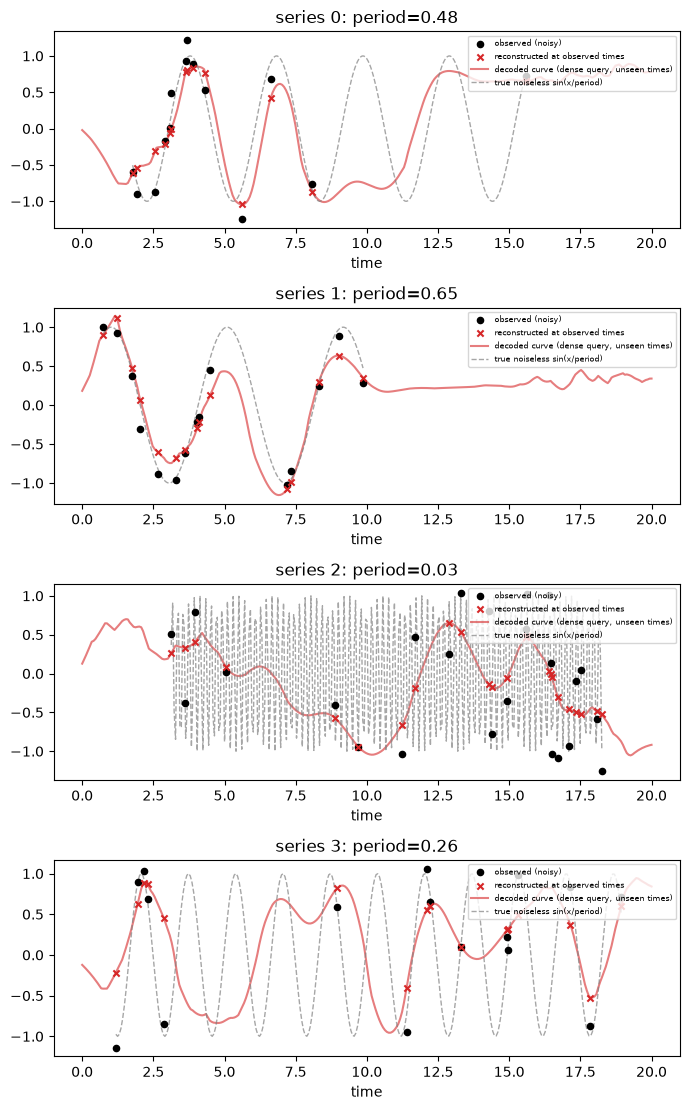

In [5]:
val_mse, val_corr = evaluate(val_loader)
print(f'Final val_mse={val_mse:.4f}  val_corr(recon,true)={val_corr:.4f}')

def reconstruction_plots(n_examples=4):
    model.eval()
    fig, axes = plt.subplots(n_examples, 1, figsize=(7, 2.8 * n_examples))
    dense_t = torch.linspace(0, 1, 300).unsqueeze(0)
    with torch.no_grad():
        for i in range(n_examples):
            xi, yi, pi = val_ds[i]
            xb, tb, _ = collate_toy_sine([(xi, yi, pi)], t_max=T_MAX)
            recon, z, _, _ = model(xb, tb)
            dense_recon, _ = model.decoder(z, dense_t)

            ax = axes[i]
            ax.scatter(xi.numpy(), yi.numpy(), c='k', s=20, zorder=3, label='observed (noisy)')
            ax.scatter(xi.numpy(), recon[0].numpy(), c='tab:red', s=20, marker='x', zorder=4,
                       label='reconstructed at observed times')
            ax.plot(dense_t[0].numpy() * T_MAX, dense_recon[0].numpy(), color='tab:red',
                    alpha=0.6, linewidth=1.5, label='decoded curve (dense query, unseen times)')
            true_curve_t = np.linspace(xi.numpy().min(), xi.numpy().max(), 300)
            ax.plot(true_curve_t, np.sin(true_curve_t / pi.item()), color='gray',
                    linestyle='--', linewidth=1, alpha=0.7, label='true noiseless sin(x/period)')
            ax.set_title(f'series {i}: period={pi.item():.2f}')
            ax.set_xlabel('time')
            ax.legend(fontsize=6, loc='upper right')
    fig.tight_layout()

reconstruction_plots()

**Read this plot carefully, not just optimistically.** Near the observed
clusters, reconstruction tracks the data reasonably well. But in the large
gaps between clusters -- especially for short-period series -- the decoded
curve drifts away from the true sine rather than continuing to oscillate
correctly. There's no periodicity inductive bias anywhere in this model;
it only has to be consistent with data where data exists, so in a gap it's
free to do whatever the GRU dynamics produce. For very short periods (e.g.
`period=0.03` below) the true signal completes hundreds of cycles across
the domain -- reconstructing that from ~20-30 irregular samples is not
just hard for this model, it's information-theoretically impossible
(classic aliasing/undersampling): many periods are consistent with the
same sparse samples. That's a property of the problem, not a bug.

## 5. Linear probe: is `period` linearly recoverable, unsupervised?

Mean-pool the `(num_ref, latent_dim)` latent sequence to one vector per
series, fit a linear regression from that vector to `period` on half the
validation set, and evaluate on the other half. `period` was never used
for training -- only for this diagnostic -- so any predictive power here
is a genuine (if indirect) signal that the reconstruction objective
organizes the representation around real structure in the data, which is
exactly what Phase 2's disentanglement loss will need to have something to
work with.

Linear probe: corr=0.582  R^2=0.327  (n_fit=250, n_test=250)


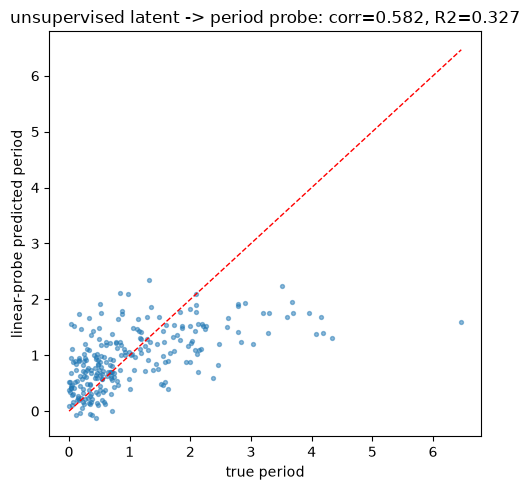

In [6]:
from sklearn.linear_model import LinearRegression

model.eval()
latents, periods = [], []
with torch.no_grad():
    for i in range(len(val_ds)):
        xi, yi, pi = val_ds[i]
        xb, tb, _ = collate_toy_sine([(xi, yi, pi)], t_max=T_MAX)
        z, _ = model.encoder(xb, tb)
        latents.append(z[0].mean(dim=0).numpy())  # mean-pool over reference points
        periods.append(pi.item())
latents = np.stack(latents)
periods = np.array(periods)

n = len(periods)
rng = np.random.default_rng(SEED)
idx = rng.permutation(n)
fit_idx, test_idx = idx[:n // 2], idx[n // 2:]

reg = LinearRegression().fit(latents[fit_idx], periods[fit_idx])
pred = reg.predict(latents[test_idx])
corr = float(np.corrcoef(pred, periods[test_idx])[0, 1])
r2 = float(reg.score(latents[test_idx], periods[test_idx]))
print(f'Linear probe: corr={corr:.3f}  R^2={r2:.3f}  (n_fit={len(fit_idx)}, n_test={len(test_idx)})')

plt.figure(figsize=(5, 5))
plt.scatter(periods[test_idx], pred, s=8, alpha=0.5)
lims = [periods[test_idx].min(), periods[test_idx].max()]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('true period'); plt.ylabel('linear-probe predicted period')
plt.title(f'unsupervised latent -> period probe: corr={corr:.3f}, R2={r2:.3f}')
plt.tight_layout()

**Comparing to the supervised baseline**: the Phase 1 supervised
regressor (trained directly on `period`) reached corr≈0.86, R²≈0.73. This
unsupervised probe comes in lower (see the printed numbers above) --
expected, since reconstruction is only an indirect proxy for recovering
`period` specifically, not optimized for it. What matters is that the
probe result is clearly above chance: the reconstruction objective alone
organizes the latent around real, linearly-accessible structure, without
ever seeing the label. That's the property Phase 2 needs.

## 6. Latent space visualization

This is a general representation-learning diagnostic, not something DIOSC
does for us -- DIOSC (Phase 2) is a training *objective* that reshapes the
latent space around independent factors; visualizing it is a separate tool
we use both now (baseline, undisentangled) and again after Phase 2, to see
what the contrastive loss actually changed.

We PCA the same mean-pooled latent vectors used for the linear probe above
down to 2D, and color by `period` (log scale, since `period ~ Gamma(1,1)`
is heavily right-skewed).

explained variance ratio: [0.9501288 0.0253744]


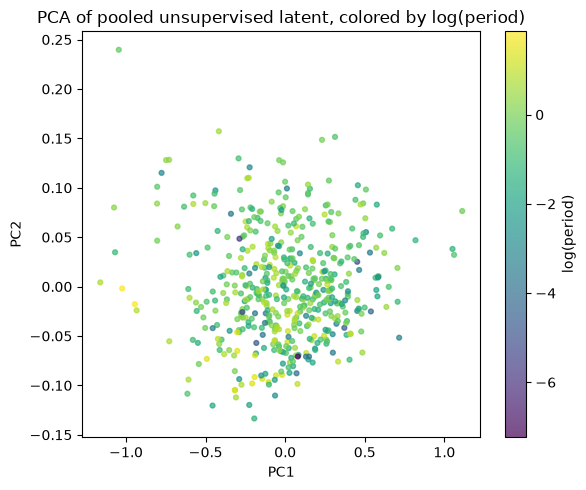

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latents)
print('explained variance ratio:', pca.explained_variance_ratio_)

plt.figure(figsize=(6, 5))
sc = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=np.log(periods), cmap='viridis', s=12, alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA of pooled unsupervised latent, colored by log(period)')
plt.colorbar(sc, label='log(period)')
plt.tight_layout()

## 7. Is the model using gap/missingness patterns as a shortcut?

mTAND's input is `[value, mask]` plus the raw timestamps as attention
keys, so the model has direct access to *where the gaps are*, separately
from the actual observed values. If gap structure happened to correlate
with `period` -- even spuriously, from overfitting a finite dataset -- the
model could exploit that instead of the signal we actually want. Worth
checking directly rather than assuming it away, since gaps here are a
nuisance of the irregular sampling, not a meaningful factor.

**Step 1: does gap structure correlate with `period` in the data itself?**
By construction, `period` is drawn independently of the timestamps, so
this should be ~0.

In [8]:
raw_periods, n_obs, mean_gap, max_gap = [], [], [], []
for x, y, period in full_ds.series:
    raw_periods.append(period)
    n_obs.append(len(x))
    gaps = np.diff(x)
    mean_gap.append(gaps.mean() if len(gaps) else 0)
    max_gap.append(gaps.max() if len(gaps) else 0)
raw_periods = np.array(raw_periods); n_obs = np.array(n_obs)
mean_gap = np.array(mean_gap); max_gap = np.array(max_gap)

print('corr(period, n_obs):    ', np.corrcoef(raw_periods, n_obs)[0, 1])
print('corr(period, mean_gap): ', np.corrcoef(raw_periods, mean_gap)[0, 1])
print('corr(period, max_gap):  ', np.corrcoef(raw_periods, max_gap)[0, 1])

corr(period, n_obs):     0.023938366080589215
corr(period, mean_gap):  -0.02150513241974822
corr(period, max_gap):   0.004053273935708471


**Step 2: does the *trained model* exploit gap structure regardless?**
Data-level independence doesn't rule out the model latching onto some
subtler function of the timing/mask pattern through overfitting. Direct
test: for each validation series, shuffle the observed **values** among
themselves while keeping the **timestamps and mask exactly as they
are** -- same gaps, same density, same clusters, just scrambled content.
Push through the trained encoder and the *same* (already-fit) linear
probe from Section 5, and see whether predictions still track the true
`period`.

If they do, the probe is finding signal in the gap pattern alone. If
performance collapses to chance, the model's real predictive power comes
from the observed values, not the missingness pattern -- which is what we
want.

In [9]:
shuf_rng = np.random.default_rng(123)

def pooled_latent_from_series(x_np, y_np, period_val, permute_values=False):
    x_t = torch.as_tensor(x_np, dtype=torch.float32)
    y_t = torch.as_tensor(y_np, dtype=torch.float32)
    if permute_values:
        y_t = y_t[shuf_rng.permutation(len(y_t))]
    xb, tb, _ = collate_toy_sine([(x_t, y_t, torch.tensor(period_val))], t_max=T_MAX)
    with torch.no_grad():
        z, _ = model.encoder(xb, tb)
    return z[0].mean(dim=0).numpy()

val_indices = val_ds.indices
latents_shuffled = np.stack([
    pooled_latent_from_series(*val_ds.dataset.series[i], permute_values=True)
    for i in val_indices
])

pred_shuffled = reg.predict(latents_shuffled[test_idx])
corr_shuffled = np.corrcoef(pred_shuffled, periods[test_idx])[0, 1]
ss_res = ((periods[test_idx] - pred_shuffled) ** 2).sum()
ss_tot = ((periods[test_idx] - periods[test_idx].mean()) ** 2).sum()
r2_shuffled = 1 - ss_res / ss_tot

print(f'Probe on REAL latents (values intact):              corr={corr:.3f}  R2={r2:.3f}')
print(f'Probe on SHUFFLED-VALUE latents (gaps/mask intact):  corr={corr_shuffled:.3f}  R2={r2_shuffled:.3f}')

Probe on REAL latents (values intact):              corr=0.582  R2=0.327
Probe on SHUFFLED-VALUE latents (gaps/mask intact):  corr=0.284  R2=-0.042


**Read R², not just the correlation, here.** R² measures improvement
over predicting the mean, so R²≈0 means "no usable signal" -- it should
drop close to 0 (or go negative, which just means worse than a constant
predictor, still "no signal") once the values are scrambled, if the model
isn't leaning on gap structure. The raw correlation coefficient is a
noisier statistic under this kind of distribution shift with only ~250
held-out points, and can stay weakly nonzero from sampling noise alone
even when there's truly nothing there -- R² is what actually tells us
whether that residual correlation is exploitable.

If R² collapses to ~0 above (it did the last time this was checked), that
confirms the model's period-signal comes from the actual observed values,
not from the timing/gap pattern -- gaps are staying a nuisance, not
becoming a shortcut, which is exactly the property we want carried into
Phase 2.

## Next: Phase 2

This gives us the unsupervised counterpart to the Phase 1 baseline: a
representation trained without labels, already carrying decodable
structure. Phase 2 attaches DIOSC's Independence-of-Support contrastive
loss to `MTANReconEncoder`'s representation (most likely the pooled latent
used for the probe above, or the full reference-point sequence -- worth
deciding once we see what DIOSC's own pair-sampling code expects), and
validates factor recovery on a synthetic dataset with 2-3 deliberately
correlated generative factors (this toy dataset only has one: `period`).